<div style="
  background: linear-gradient(135deg, #667eea, #764ba2, #ff9a9e);
  padding: 32px;
  border-radius: 24px;
  text-align: center;
  color: #ffffff;
  box-shadow: 0 8px 20px rgba(0,0,0,0.15);
  margin-bottom: 20px;
">
  <h1 style="font-size: 42px; margin-bottom: 8px;">🎲 Bayesian Probability Simulation 🔬</h1>
  <h2 style="font-size: 24px; margin-top: 0; color: #f0e6ff;">From Conditional Probability to Naive Bayes Classification</h2>
  <p style="font-size: 18px; line-height: 1.7; color: #f0e6ff;">
    A refactored, simulation-driven exploration of Bayesian inference, Monte Carlo convergence,<br>
    and text classification — with corrected theory and reproducible R code.
  </p>
  <div style="background-color: rgba(255,255,255,0.18); display: inline-block; padding: 10px 18px;
              border-radius: 18px; margin-top: 12px; font-size: 16px; color: #ffffff;">
    R &nbsp;•&nbsp; Bayes' Theorem &nbsp;•&nbsp; Law of Total Probability &nbsp;•&nbsp; Monte Carlo &nbsp;•&nbsp; Naive Bayes
  </div>
</div>

### Notebook Overview

This notebook presents a **question-free, explanation-driven** exploration of Bayesian concepts. Each section presents the **analytical derivation** followed immediately by a **Monte Carlo simulation** that validates it.

| Part | Topic | Core Concept |
|------|-------|--------------|
| 1.1 | Airport Security Scanner | Law of Total Probability & Bayes' theorem, simulation convergence |
| 1.2 | Fraud Detection | Bayes' theorem with one and two conditionally independent features |
| 2.1 | Monty Hall Problem | Conditional probability, switching vs staying |
| 2.2 | Infinite Monkey Theorem | Rare events, geometric / binomial intuition, `1-(1-p)^N` |
| 3 | Spam Email Classification | Bernoulli Naive Bayes from scratch, data leakage avoidance, Laplace smoothing |

**Reproducibility:** `set.seed(9248)` () is set before every stochastic block. Analytical values are printed alongside empirical estimates.


In [1]:
# Global reproducibility and libraries
set.seed(9248)
# Required libraries (install once externally: install.packages(c("tm","SnowballC","e1071","caret")))
library(tm)
library(SnowballC)
library(e1071)
# library(caret)  # not needed — manual stratified sampling used


Loading required package: NLP



<div style="
  background: linear-gradient(135deg, #74c69d, #48cae4);
  padding: 26px;
  border-radius: 22px;
  margin-top: 28px;
  border: 4px solid #2d6a4f;
  box-shadow: 0 8px 22px rgba(0, 0, 0, 0.18);
  color: #081c15;
">
  <h1 style="color: #081c15; background-color: rgba(255,255,255,0.65); padding: 12px 16px; border-radius: 14px; margin-top: 0;">
    📡 Part 1 — Bayesian Reasoning with Simulation
  </h1>
  <p style="font-size: 17px; line-height: 1.7; color: #133f30; font-weight: 500;">
    Intuition and simulation of fundamental probability concepts: Law of Total Probability, Bayes' theorem,
    and how empirical frequencies converge to theoretical values as predicted by the Law of Large Numbers.
  </p>
</div>

<div style="
  background: linear-gradient(135deg, #a8edea, #fed6e3);
  padding: 24px;
  border-radius: 22px;
  margin-top: 28px;
  border: 4px solid #8e6fa0;
  box-shadow: 0 8px 20px rgba(0,0,0,0.12);
  color: #1a1a2e;
">
  <h1 style="color: #2b0a2a; background-color: rgba(255,255,255,0.55); padding: 10px 16px; border-radius: 14px; margin-top: 0; font-size: 26px;">
    ✈️ 1.1 Airport Security System — Law of Total Probability & Conditional Probability
  </h1>
  <p style="font-size: 16px; line-height: 1.7; color: #2b0a2a;">
    Scenario: an airport scanner detects prohibited objects. We derive <code>P(Alarm)</code> and
    <code>P(Object | Alarm)</code> and validate them with a Monte Carlo experiment.
  </p>
</div>

#### 1.1.1 Analytical Derivation

Given:

* $P(\text{Object}) = 0.05$
* $P(\text{Alarm} \mid \text{Object}) = 0.90$
* $P(\text{Alarm} \mid \neg\text{Object}) = 0.08$

**Law of Total Probability:**

$$P(\text{Alarm}) = P(\text{Alarm}\mid\text{Object})P(\text{Object}) + P(\text{Alarm}\mid\neg\text{Object})P(\neg\text{Object})$$

$$= 0.90 \times 0.05 + 0.08 \times 0.95 = 0.045 + 0.076 = 0.121$$

**Bayes' theorem:**

$$P(\text{Object}\mid\text{Alarm}) = \frac{P(\text{Alarm}\mid\text{Object})P(\text{Object})}{P(\text{Alarm})} = \frac{0.045}{0.121} = \frac{45}{121} \approx 0.3719$$

Note $P(\neg\text{Object}) = 1 - P(\text{Object}) = 0.95$ is used explicitly.


In [2]:
# 1.1 — Analytical calculation (code implements the formulas)
p_object <- 0.05
p_alarm_given_object <- 0.90
p_alarm_given_no_object <- 0.08

p_alarm <- p_alarm_given_object * p_object + p_alarm_given_no_object * (1 - p_object)
p_object_given_alarm <- (p_alarm_given_object * p_object) / p_alarm

cat(sprintf("P(Alarm) = %.4f\n", p_alarm))
cat(sprintf("P(Object|Alarm) = %.4f  (45/121 = %.4f)\n", p_object_given_alarm, 45/121))


P(Alarm) = 0.1210
P(Object|Alarm) = 0.3719  (45/121 = 0.3719)


#### 1.1.2 Monte Carlo Simulation (Corrected)


* `object_status ~ Bernoulli(p_object)`  via `rbinom(N, 1, p_object)`
* `alarm | object ~ Bernoulli(p_alarm_given_object)` and `alarm | \neg object ~ Bernoulli(p_alarm_given_no_object)` via `rbinom` per group.

This preserves $\text{Var}(\text{count}) = Np(1-p)$ and satisfies the Law of Large Numbers.


In [3]:
# 1.1 — Simulation with correct Bernoulli draws (N = 100,000)
set.seed(9248)
N <- 100000

# Each passenger independently has object with prob p_object
object_status <- rbinom(N, 1, p_object)

alarm <- integer(N)
idx_obj <- which(object_status == 1)
idx_no_obj <- which(object_status == 0)

alarm[idx_obj] <- rbinom(length(idx_obj), 1, p_alarm_given_object)
alarm[idx_no_obj] <- rbinom(length(idx_no_obj), 1, p_alarm_given_no_object)

emp_p_alarm <- mean(alarm == 1)
# Guard against zero alarms (NaN)
emp_p_object_given_alarm <- if (sum(alarm == 1) == 0) NA else mean(object_status[alarm == 1] == 1)

cat(sprintf("Empirical P(Alarm)         = %.4f (theoretical %.4f)\n", emp_p_alarm, p_alarm))
cat(sprintf("Empirical P(Object|Alarm)  = %.4f (theoretical %.4f)\n", emp_p_object_given_alarm, p_object_given_alarm))


Empirical P(Alarm)         = 0.1217 (theoretical 0.1210)
Empirical P(Object|Alarm)  = 0.3780 (theoretical 0.3719)


#### 1.1.3 Analytical vs Empirical Comparison


pdf 
  2

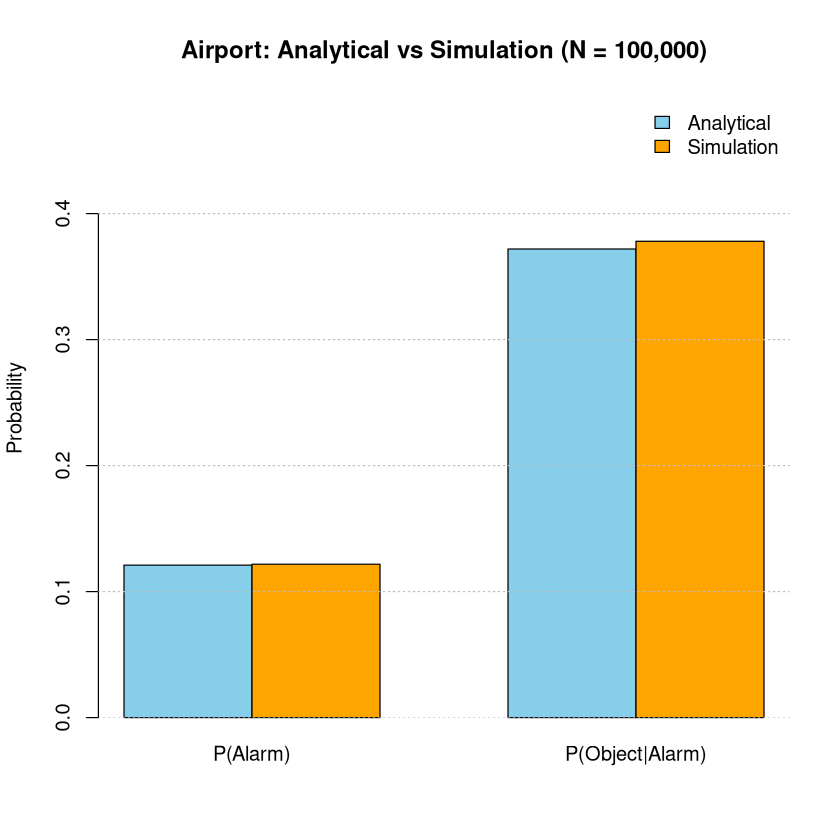

In [4]:
# 1.1 — Bar chart: analytical vs simulation
png("results/airport_comparison.png", width=900, height=700, res=120)
par(mar=c(5,5,4,2))
bar_positions <- barplot(
  height = rbind(c(p_alarm, p_object_given_alarm), c(emp_p_alarm, emp_p_object_given_alarm)),
  beside = TRUE,
  names.arg = c("P(Alarm)", "P(Object|Alarm)"),
  col = c("skyblue", "orange"),
  ylim = c(0, max(c(p_alarm, p_object_given_alarm, emp_p_alarm, emp_p_object_given_alarm), na.rm=TRUE) * 1.3),
  main = "Airport: Analytical vs Simulation (N = 100,000)",
  ylab = "Probability",
  border = "black",
  cex.names = 1.1, cex.lab = 1.1
)
legend("topright", legend = c("Analytical", "Simulation"), fill = c("skyblue", "orange"), bty = "n", cex=1.05)
grid(nx = NA, ny = NULL, col = "gray", lty = "dotted")
# annotate values
text(bar_positions, rbind(c(p_alarm, p_object_given_alarm), c(emp_p_alarm, emp_p_object_given_alarm)) + 0.015,
     labels = sprintf("%.3f", rbind(c(p_alarm, p_object_given_alarm), c(emp_p_alarm, emp_p_object_given_alarm))),
     cex=0.85)
dev.off()

bar_positions <- barplot(
  height = rbind(c(p_alarm, p_object_given_alarm), c(emp_p_alarm, emp_p_object_given_alarm)),
  beside = TRUE,
  names.arg = c("P(Alarm)", "P(Object|Alarm)"),
  col = c("skyblue", "orange"),
  ylim = c(0, max(c(p_alarm, p_object_given_alarm, emp_p_alarm, emp_p_object_given_alarm), na.rm=TRUE) * 1.3),
  main = "Airport: Analytical vs Simulation (N = 100,000)",
  ylab = "Probability",
  border = "black"
)
legend("topright", legend = c("Analytical", "Simulation"), fill = c("skyblue", "orange"), bty = "n")
grid(nx = NA, ny = NULL, col = "gray", lty = "dotted")


#### 1.1.4 Convergence Analysis



      N   Mean     SD Theoretical
1 1e+01 0.3541 0.3983      0.3719
2 1e+02 0.3857 0.1453      0.3719
3 5e+02 0.3740 0.0606      0.3719
4 1e+03 0.3773 0.0427      0.3719
5 5e+03 0.3713 0.0184      0.3719
6 1e+04 0.3696 0.0147      0.3719
7 5e+04 0.3714 0.0063      0.3719
8 1e+05 0.3720 0.0046      0.3719


pdf 
  2

Warning message in title(...):
“conversion failure on 'Convergence of P(Object|Alarm) — Mean +- SD over 300 replicates' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in title(...):
“conversion failure on 'Convergence of P(Object|Alarm) — Mean +- SD over 300 replicates' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in title(...):
“conversion failure on 'Convergence of P(Object|Alarm) — Mean +- SD over 300 replicates' in 'mbcsToSbcs': dot substituted for <94>”


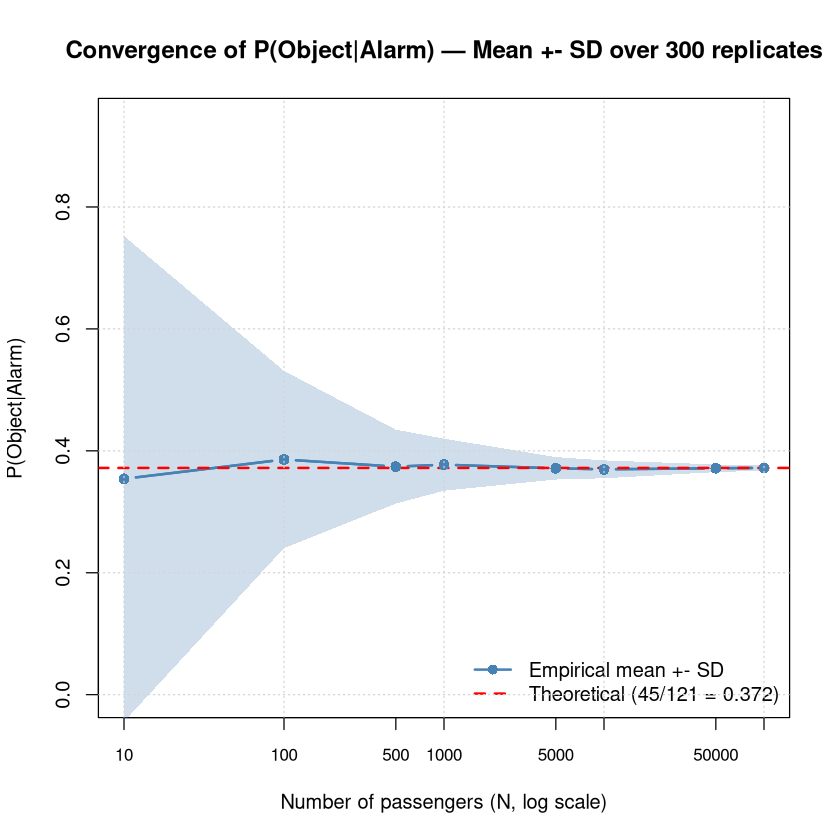

In [5]:
# 1.1 — Convergence: mean +- SD over B replicates per N
set.seed(9248)
Ns <- c(10, 100, 500, 1000, 5000, 10000, 50000, 100000)
B <- 300

emp_means <- numeric(length(Ns))
emp_sds <- numeric(length(Ns))

for (i in seq_along(Ns)) {
  n <- Ns[i]
  reps <- replicate(B, {
    obj <- rbinom(n, 1, p_object)
    al <- integer(n)
    io <- which(obj==1); ino <- which(obj==0)
    if (length(io)>0) al[io] <- rbinom(length(io), 1, p_alarm_given_object)
    if (length(ino)>0) al[ino] <- rbinom(length(ino), 1, p_alarm_given_no_object)
    if (sum(al==1)==0) NA else mean(obj[al==1]==1)
  })
  emp_means[i] <- mean(reps, na.rm=TRUE)
  emp_sds[i] <- sd(reps, na.rm=TRUE)
}

# Table
print(data.frame(N=Ns, Mean=round(emp_means,4), SD=round(emp_sds,4), Theoretical=round(p_object_given_alarm,4)))

# Plot
png("results/airport_convergence.png", width=1000, height=600, res=120)
plot(Ns, emp_means, type="b", pch=16, col="steelblue", lwd=2, log="x",
     main = "Convergence of P(Object|Alarm) — Mean +- SD over 300 replicates",
     xlab = "Number of passengers (N, log scale)", ylab = "P(Object|Alarm)",
     ylim = c(0, max(c(emp_means+emp_sds, p_object_given_alarm), na.rm=TRUE)*1.25),
     xaxt="n")
axis(1, at=Ns, labels=Ns, cex.axis=0.85)
# SD band
polygon(c(Ns, rev(Ns)), c(emp_means-emp_sds, rev(emp_means+emp_sds)), col=rgb(0.27,0.51,0.71,0.25), border=NA)
lines(Ns, emp_means, type="b", pch=16, col="steelblue", lwd=2)
abline(h=p_object_given_alarm, col="red", lty=2, lwd=2)
points(Ns, emp_means, pch=16, col="steelblue", cex=1.2)
legend("bottomright", legend=c("Empirical mean +- SD", "Theoretical (45/121 = 0.372)"),
       col=c("steelblue","red"), lty=c(1,2), pch=c(16,NA), pt.cex=1.1, lwd=2, bty="n")
grid()
dev.off()

plot(Ns, emp_means, type="b", pch=16, col="steelblue", lwd=2, log="x",
     main = "Convergence of P(Object|Alarm) — Mean +- SD over 300 replicates",
     xlab = "Number of passengers (N, log scale)", ylab = "P(Object|Alarm)",
     ylim = c(0, max(c(emp_means+emp_sds, p_object_given_alarm), na.rm=TRUE)*1.25),
     xaxt="n")
axis(1, at=Ns, labels=Ns, cex.axis=0.85)
polygon(c(Ns, rev(Ns)), c(emp_means-emp_sds, rev(emp_means+emp_sds)), col=rgb(0.27,0.51,0.71,0.25), border=NA)
lines(Ns, emp_means, type="b", pch=16, col="steelblue", lwd=2)
abline(h=p_object_given_alarm, col="red", lty=2, lwd=2)
points(Ns, emp_means, pch=16, col="steelblue", cex=1.2)
legend("bottomright", legend=c("Empirical mean +- SD", "Theoretical (45/121 = 0.372)"),
       col=c("steelblue","red"), lty=c(1,2), pch=c(16,NA), pt.cex=1.1, lwd=2, bty="n")
grid()


<div style="
  background: linear-gradient(135deg, #e8b7e8, #ffb6f4);
  padding: 24px;
  border-radius: 22px;
  margin-top: 28px;
  border: 4px solid #481344;
  box-shadow: 0 8px 20px rgba(0,0,0,0.12);
  color: #2b0a2a;
">
  <h1 style="color: #2b0a2a; background-color: rgba(255,255,255,0.55); padding: 10px 16px; border-radius: 14px; margin-top: 0; font-size: 26px;">
    💳 1.2 Fraud Detection — Bayes' Theorem with One and Two Features
  </h1>
  <p style="font-size: 16px; line-height: 1.7; color: #2b0a2a;">
    Single-feature posterior <code>P(Fraud | OddCountry)</code> and the Naive Bayes extension
    <code>P(Fraud | OddCountry, LargeAmount)</code> under conditional independence.
  </p>
</div>

#### 1.2.1 Analytical Derivation — Single Feature

Given:

* $P(\text{Fraud}) = 0.02$
* $P(\text{OddCountry} \mid \text{Fraud}) = 0.70$
* $P(\text{OddCountry} \mid \neg\text{Fraud}) = 0.05$
* $P(\text{LargeAmount} \mid \text{Fraud}) = 0.60$
* $P(\text{LargeAmount} \mid \neg\text{Fraud}) = 0.10$

**Step 1 — $P(\text{OddCountry})$ via LTP:**

$$P(\text{Odd}) = 0.70\times0.02 + 0.05\times0.98 = 0.014 + 0.049 = 0.063$$

**Step 2 — Bayes:**

$$P(\text{Fraud}\mid\text{Odd}) = \frac{0.70\times0.02}{0.063} = \frac{0.014}{0.063} = \frac{14}{63} \approx 0.2222$$

**Step 3 — Two features (Naive Bayes assumption):**

Assume **conditional independence** given fraud:

$$P(\text{Odd},\text{Large}\mid\text{Fraud}) = P(\text{Odd}\mid\text{Fraud})\cdot P(\text{Large}\mid\text{Fraud}) = 0.42$$

$$P(\text{Odd},\text{Large}\mid\neg\text{Fraud}) = 0.05\times0.10 = 0.005$$

Then

$$P(\text{Odd},\text{Large}) = 0.42\times0.02 + 0.005\times0.98 = 0.0084 + 0.0049 = 0.0133$$

$$P(\text{Fraud}\mid\text{Odd},\text{Large}) = \frac{0.0084}{0.0133} = \frac{84}{133} \approx 0.6316$$



In [6]:
# 1.2 — Analytical
p_fraud <- 0.02
p_odd_if_fraud <- 0.70
p_odd_if_no <- 0.05
p_large_if_fraud <- 0.60
p_large_if_no <- 0.10

p_odd <- p_odd_if_fraud * p_fraud + p_odd_if_no * (1 - p_fraud)
p_fraud_if_odd <- (p_odd_if_fraud * p_fraud) / p_odd

p_joint <- p_odd_if_fraud * p_large_if_fraud * p_fraud + p_odd_if_no * p_large_if_no * (1 - p_fraud)
p_fraud_if_odd_large <- (p_odd_if_fraud * p_large_if_fraud * p_fraud) / p_joint

cat(sprintf("P(Odd) = %.4f\n", p_odd))
cat(sprintf("P(Fraud|Odd) = %.4f  (14/63 = %.4f)\n", p_fraud_if_odd, 14/63))
cat(sprintf("P(Odd,Large) = %.4f\n", p_joint))
cat(sprintf("P(Fraud|Odd,Large) = %.4f  (84/133 = %.4f)\n", p_fraud_if_odd_large, 84/133))


P(Odd) = 0.0630
P(Fraud|Odd) = 0.2222  (14/63 = 0.2222)
P(Odd,Large) = 0.0133
P(Fraud|Odd,Large) = 0.6316  (84/133 = 0.6316)


#### 1.2.2 Dataset Simulation (N = 200,000)


In [7]:
# 1.2 — Synthetic dataset with correct rbinom per conditional group
set.seed(9248)
N <- 200000

fraud_label <- rbinom(N, 1, p_fraud)
odd_country <- integer(N)
large_amount <- integer(N)
idx_fraud <- which(fraud_label==1)
idx_no <- which(fraud_label==0)

odd_country[idx_fraud] <- rbinom(length(idx_fraud), 1, p_odd_if_fraud)
odd_country[idx_no]    <- rbinom(length(idx_no), 1, p_odd_if_no)

large_amount[idx_fraud] <- rbinom(length(idx_fraud), 1, p_large_if_fraud)
large_amount[idx_no]    <- rbinom(length(idx_no), 1, p_large_if_no)

df <- data.frame(Fraud=fraud_label, OddCountry=odd_country, LargeAmount=large_amount)

emp_p_fraud_if_odd <- mean(df$Fraud[df$OddCountry==1]==1)
emp_p_fraud_if_odd_large <- mean(df$Fraud[df$OddCountry==1 & df$LargeAmount==1]==1)

cat(sprintf("Empirical P(Fraud|Odd)        = %.4f (theoretical %.4f)\n", emp_p_fraud_if_odd, p_fraud_if_odd))
cat(sprintf("Empirical P(Fraud|Odd,Large)  = %.4f (theoretical %.4f)\n", emp_p_fraud_if_odd_large, p_fraud_if_odd_large))


Empirical P(Fraud|Odd)        = 0.2207 (theoretical 0.2222)
Empirical P(Fraud|Odd,Large)  = 0.6197 (theoretical 0.6316)


pdf 
  2

Warning message in title(main = main, sub = sub, xlab = xlab, ylab = ylab, ...):
“conversion failure on 'P(Fraud | OddCountry) — Analytical vs Empirical' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in title(main = main, sub = sub, xlab = xlab, ylab = ylab, ...):
“conversion failure on 'P(Fraud | OddCountry) — Analytical vs Empirical' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in title(main = main, sub = sub, xlab = xlab, ylab = ylab, ...):
“conversion failure on 'P(Fraud | OddCountry) — Analytical vs Empirical' in 'mbcsToSbcs': dot substituted for <94>”


pdf 
  2

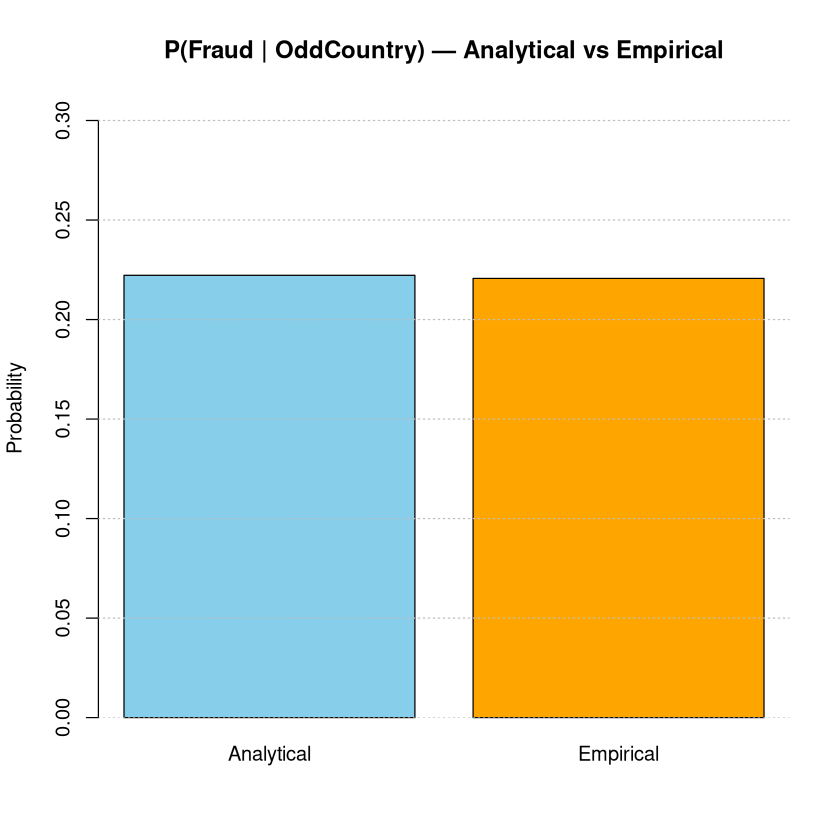

Warning message in title(main = main, sub = sub, xlab = xlab, ylab = ylab, ...):
“conversion failure on 'P(Fraud | OddCountry & LargeAmount) — Analytical vs Empirical' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in title(main = main, sub = sub, xlab = xlab, ylab = ylab, ...):
“conversion failure on 'P(Fraud | OddCountry & LargeAmount) — Analytical vs Empirical' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in title(main = main, sub = sub, xlab = xlab, ylab = ylab, ...):
“conversion failure on 'P(Fraud | OddCountry & LargeAmount) — Analytical vs Empirical' in 'mbcsToSbcs': dot substituted for <94>”


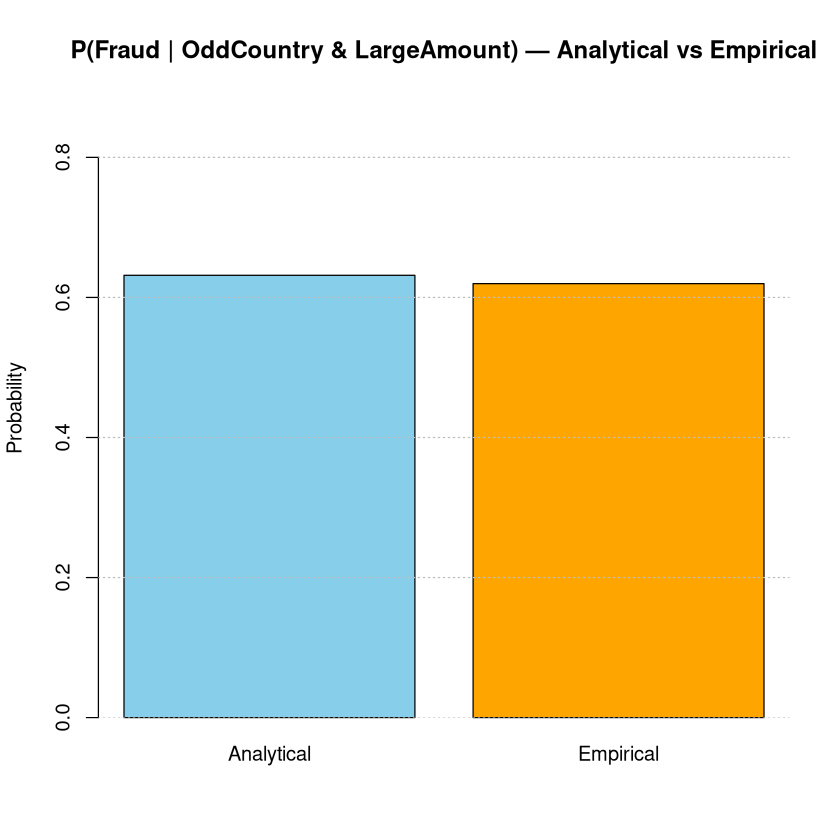

In [8]:
# 1.2 — Comparison bar charts
png("results/fraud_single_comparison.png", width=800, height=600, res=120)
par(mar=c(5,5,4,2))
bp <- barplot(c(p_fraud_if_odd, emp_p_fraud_if_odd),
        names.arg=c("Analytical","Empirical"), col=c("skyblue","orange"), border="black",
        main="P(Fraud | OddCountry) — Analytical vs Empirical", ylab="Probability",
        ylim=c(0, max(c(p_fraud_if_odd, emp_p_fraud_if_odd))*1.4))
text(bp, c(p_fraud_if_odd, emp_p_fraud_if_odd)+0.015, sprintf("%.3f", c(p_fraud_if_odd, emp_p_fraud_if_odd)), cex=0.9)
grid(nx=NA, ny=NULL, col="gray", lty="dotted")
dev.off()
barplot(c(p_fraud_if_odd, emp_p_fraud_if_odd),
        names.arg=c("Analytical","Empirical"), col=c("skyblue","orange"), border="black",
        main="P(Fraud | OddCountry) — Analytical vs Empirical", ylab="Probability",
        ylim=c(0, max(c(p_fraud_if_odd, emp_p_fraud_if_odd))*1.4))
grid(nx=NA, ny=NULL, col="gray", lty="dotted")

png("results/fraud_joint_comparison.png", width=800, height=600, res=120)
par(mar=c(5,5,4,2))
bp <- barplot(c(p_fraud_if_odd_large, emp_p_fraud_if_odd_large),
        names.arg=c("Analytical","Empirical"), col=c("skyblue","orange"), border="black",
        main="P(Fraud | OddCountry & LargeAmount) — Analytical vs Empirical", ylab="Probability",
        ylim=c(0, max(c(p_fraud_if_odd_large, emp_p_fraud_if_odd_large))*1.4))
text(bp, c(p_fraud_if_odd_large, emp_p_fraud_if_odd_large)+0.02, sprintf("%.3f", c(p_fraud_if_odd_large, emp_p_fraud_if_odd_large)), cex=0.9)
grid(nx=NA, ny=NULL, col="gray", lty="dotted")
dev.off()
barplot(c(p_fraud_if_odd_large, emp_p_fraud_if_odd_large),
        names.arg=c("Analytical","Empirical"), col=c("skyblue","orange"), border="black",
        main="P(Fraud | OddCountry & LargeAmount) — Analytical vs Empirical", ylab="Probability",
        ylim=c(0, max(c(p_fraud_if_odd_large, emp_p_fraud_if_odd_large))*1.4))
grid(nx=NA, ny=NULL, col="gray", lty="dotted")


#### 1.2.3 Convergence for P(Fraud | Odd, Large)

Same fix as 1.1.4: replicate each $N$ $B=200$ times to estimate mean±SD, rather than a single noisy 0/1 draw.


      N   Mean     SD Theoretical
1 1e+03 0.6307 0.1320      0.6316
2 5e+03 0.6336 0.0640      0.6316
3 1e+04 0.6287 0.0450      0.6316
4 5e+04 0.6330 0.0187      0.6316
5 1e+05 0.6310 0.0127      0.6316
6 2e+05 0.6309 0.0096      0.6316


pdf 
  2

Warning message in title(...):
“conversion failure on 'Convergence of P(Fraud|Odd,Large) — Mean +- SD over 200 replicates' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in title(...):
“conversion failure on 'Convergence of P(Fraud|Odd,Large) — Mean +- SD over 200 replicates' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in title(...):
“conversion failure on 'Convergence of P(Fraud|Odd,Large) — Mean +- SD over 200 replicates' in 'mbcsToSbcs': dot substituted for <94>”


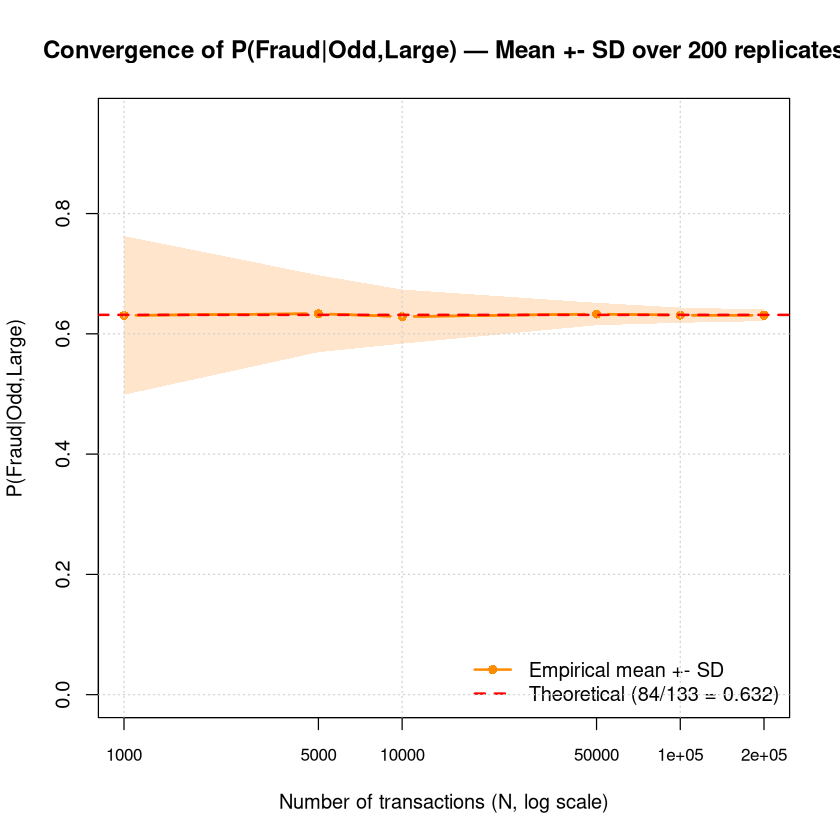

In [9]:
# 1.2 — Convergence (replicated)
set.seed(9248)
Ns2 <- c(1000, 5000, 10000, 50000, 100000, 200000)
B2 <- 200
emp_means2 <- numeric(length(Ns2)); emp_sds2 <- numeric(length(Ns2))

for (i in seq_along(Ns2)) {
  n <- Ns2[i]
  reps <- replicate(B2, {
    fl <- rbinom(n, 1, p_fraud)
    oc <- la <- integer(n)
    idxf <- which(fl==1); idxn <- which(fl==0)
    oc[idxf] <- rbinom(length(idxf),1,p_odd_if_fraud); oc[idxn] <- rbinom(length(idxn),1,p_odd_if_no)
    la[idxf] <- rbinom(length(idxf),1,p_large_if_fraud); la[idxn] <- rbinom(length(idxn),1,p_large_if_no)
    sel <- which(oc==1 & la==1)
    if (length(sel)==0) NA else mean(fl[sel]==1)
  })
  emp_means2[i] <- mean(reps, na.rm=TRUE)
  emp_sds2[i] <- sd(reps, na.rm=TRUE)
}
print(data.frame(N=Ns2, Mean=round(emp_means2,4), SD=round(emp_sds2,4), Theoretical=round(p_fraud_if_odd_large,4)))

png("results/fraud_convergence.png", width=1000, height=600, res=120)
plot(Ns2, emp_means2, type="b", pch=16, col="darkorange", lwd=2, log="x",
     main="Convergence of P(Fraud|Odd,Large) — Mean +- SD over 200 replicates",
     xlab="Number of transactions (N, log scale)", ylab="P(Fraud|Odd,Large)",
     ylim=c(0, max(c(emp_means2+emp_sds2, p_fraud_if_odd_large), na.rm=TRUE)*1.25), xaxt="n")
axis(1, at=Ns2, labels=Ns2, cex.axis=0.85)
polygon(c(Ns2, rev(Ns2)), c(emp_means2-emp_sds2, rev(emp_means2+emp_sds2)), col=rgb(1,0.5,0,0.2), border=NA)
lines(Ns2, emp_means2, type="b", pch=16, col="darkorange", lwd=2)
abline(h=p_fraud_if_odd_large, col="red", lty=2, lwd=2)
legend("bottomright", legend=c("Empirical mean +- SD","Theoretical (84/133 = 0.632)"),
       col=c("darkorange","red"), lty=c(1,2), pch=c(16,NA), lwd=2, bty="n")
grid()
dev.off()

plot(Ns2, emp_means2, type="b", pch=16, col="darkorange", lwd=2, log="x",
     main="Convergence of P(Fraud|Odd,Large) — Mean +- SD over 200 replicates",
     xlab="Number of transactions (N, log scale)", ylab="P(Fraud|Odd,Large)",
     ylim=c(0, max(c(emp_means2+emp_sds2, p_fraud_if_odd_large), na.rm=TRUE)*1.25), xaxt="n")
axis(1, at=Ns2, labels=Ns2, cex.axis=0.85)
polygon(c(Ns2, rev(Ns2)), c(emp_means2-emp_sds2, rev(emp_means2+emp_sds2)), col=rgb(1,0.5,0,0.2), border=NA)
lines(Ns2, emp_means2, type="b", pch=16, col="darkorange", lwd=2)
abline(h=p_fraud_if_odd_large, col="red", lty=2, lwd=2)
legend("bottomright", legend=c("Empirical mean +- SD","Theoretical (84/133 = 0.632)"),
       col=c("darkorange","red"), lty=c(1,2), pch=c(16,NA), lwd=2, bty="n")
grid()


#### 1.2.4 Sensitivity Insight

Transactions that are **both** from an odd country **and** have a large amount raise $P(\text{Fraud})$ from $0.02$ (base rate) → $0.222$ (odd only) → $0.632$ (both). This illustrates how combining independent cues multiplicatively under Naive Bayes amplifies the posterior, even when each cue is weak alone.


<div style="
  background: linear-gradient(135deg, #9668b1, #8fb5d7, #78b9f6);
  padding: 30px;
  border-radius: 26px;
  text-align: center;
  color: #1d3557;
  box-shadow: 0 8px 22px rgba(0,0,0,0.16);
  margin-top: 28px;
">
  <h1 style="font-size: 34px; margin-bottom: 8px;">🎭 Part 2 — Classic Probability Puzzles</h1>
  <h2 style="font-size: 22px; margin-top: 0;">Monty Hall and the Infinite Monkey — intuition through exhaustive simulation</h2>
  <p style="font-size: 17px; line-height: 1.7;">
    Famous thought experiments that challenge intuition and are resolved cleanly by conditional probability and the law of large numbers.
  </p>
</div>

<div style="
  background: linear-gradient(135deg, #7dbcf3, #9ff98d, #d6a870);
  padding: 24px;
  border-radius: 22px;
  margin-top: 28px;
  border: 4px solid #3a6b35;
  box-shadow: 0 8px 20px rgba(0,0,0,0.15);
  color: #1d3557;
">
  <h1 style="color: #1d3557; background-color: rgba(255,255,255,0.60); padding: 10px 16px; border-radius: 14px; margin-top: 0; font-size: 26px;">
    🚪 2.1 Monty Hall Problem
  </h1>
  <p style="font-size: 16px; line-height: 1.7; color: #1d3557;">
    Three doors, one prize. After the host opens an empty door, should you switch?
  </p>
</div>

#### 2.1.1 Analytical Solution

Let the prize be uniformly random among 3 doors. Without loss, the player picks door 1.

* If prize is door 1 (prob $1/3$): staying wins, switching loses.
* If prize is door 2 or 3 (prob $2/3$): staying loses, switching wins (host is forced to open the other empty door).

Therefore:

$$P(\text{Win} \mid \text{Stay}) = \frac{1}{3}, \qquad P(\text{Win} \mid \text{Switch}) = \frac{2}{3}$$

Switching doubles the winning probability. The host's action **conditions** on the player's choice and reveals information.


In [10]:
# 2.1 — Analytical
p_win_if_switch <- 2/3
p_win_if_stay   <- 1/3
cat(sprintf("P(Win|Switch) = %.4f\nP(Win|Stay)   = %.4f\n", p_win_if_switch, p_win_if_stay))


P(Win|Switch) = 0.6667
P(Win|Stay)   = 0.3333


In [11]:
# 2.1 — Simulation (vectorized Monty logic, seed fixed)
set.seed(9248)
N <- 10000
doors <- 1:3

simulate_monty <- function(switch=TRUE) {
  wins <- 0L
  for (i in 1:N) {
    prize <- sample(doors, 1)
    choice <- sample(doors, 1)
    # Host opens an empty door not chosen and not prize
    if (choice == prize) {
      monty <- sample(setdiff(doors, prize), 1)
    } else {
      monty <- setdiff(doors, c(choice, prize))  # single deterministic door
    }
    final <- if (switch) setdiff(doors, c(choice, monty)) else choice
    if (final == prize) wins <- wins + 1L
  }
  wins / N
}

# Run both policies separately for clarity (could also compute both in one loop)
set.seed(9248)
emp_win_switch <- simulate_monty(switch=TRUE)
set.seed(9248)
# For stay, we reuse same prize/choice sequence for paired comparison by inlining:
wins_stay <- 0; wins_switch <- 0
set.seed(9248)
for (i in 1:N) {
  prize <- sample(doors,1); choice <- sample(doors,1)
  if (choice==prize) monty <- sample(setdiff(doors, prize),1) else monty <- setdiff(doors, c(choice,prize))
  switch_to <- setdiff(doors, c(choice, monty))
  if (choice==prize) wins_stay <- wins_stay+1
  if (switch_to==prize) wins_switch <- wins_switch+1
}
emp_p_win_if_switch <- wins_switch / N
emp_p_win_if_stay <- wins_stay / N

cat(sprintf("Empirical P(Win|Switch) = %.4f (theoretical %.4f)\n", emp_p_win_if_switch, p_win_if_switch))
cat(sprintf("Empirical P(Win|Stay)   = %.4f (theoretical %.4f)\n", emp_p_win_if_stay, p_win_if_stay))


Empirical P(Win|Switch) = 0.6575 (theoretical 0.6667)
Empirical P(Win|Stay)   = 0.3425 (theoretical 0.3333)


pdf 
  2

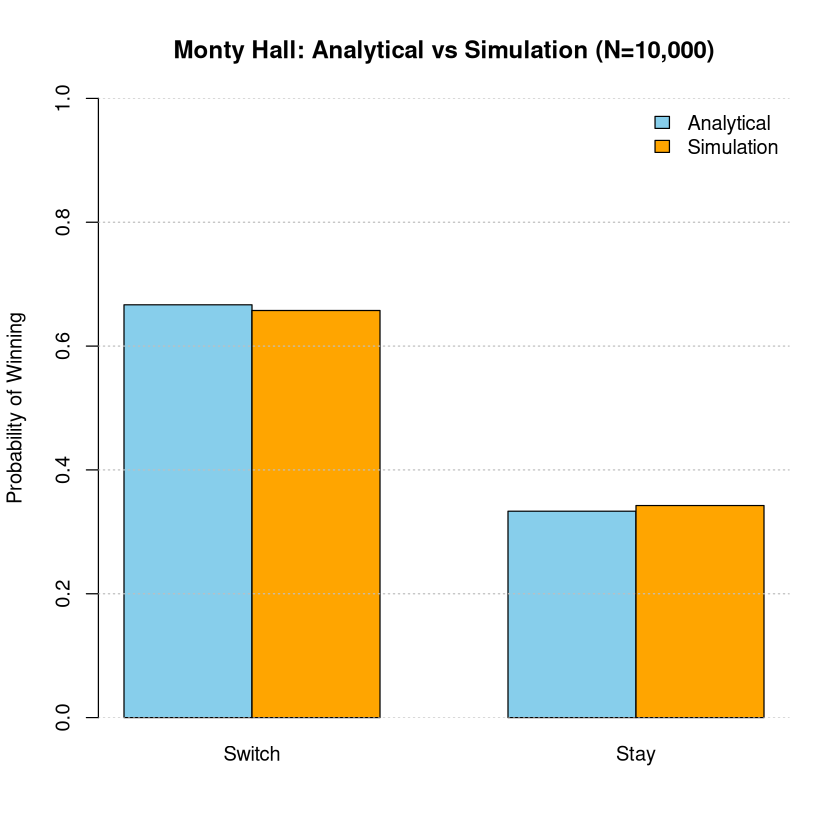

In [12]:
# 2.1 — Comparison bar chart
png("results/monty_comparison.png", width=850, height=600, res=120)
par(mar=c(5,5,4,2))
bp <- barplot(rbind(c(p_win_if_switch, p_win_if_stay), c(emp_p_win_if_switch, emp_p_win_if_stay)),
        beside=TRUE, names.arg=c("Switch","Stay"), col=c("skyblue","orange"),
        ylim=c(0,1), ylab="Probability of Winning", main="Monty Hall: Analytical vs Simulation (N=10,000)", border="black")
legend("topright", legend=c("Analytical","Simulation"), fill=c("skyblue","orange"), bty="n")
grid(nx=NA, ny=NULL, col="gray", lty="dotted")
text(bp, rbind(c(p_win_if_switch, p_win_if_stay), c(emp_p_win_if_switch, emp_p_win_if_stay))+0.03,
     sprintf("%.3f", rbind(c(p_win_if_switch, p_win_if_stay), c(emp_p_win_if_switch, emp_p_win_if_stay))), cex=0.9)
dev.off()

barplot(rbind(c(p_win_if_switch, p_win_if_stay), c(emp_p_win_if_switch, emp_p_win_if_stay)),
        beside=TRUE, names.arg=c("Switch","Stay"), col=c("skyblue","orange"),
        ylim=c(0,1), ylab="Probability of Winning", main="Monty Hall: Analytical vs Simulation (N=10,000)", border="black")
legend("topright", legend=c("Analytical","Simulation"), fill=c("skyblue","orange"), bty="n")
grid(nx=NA, ny=NULL, col="gray", lty="dotted")


<div style="
  background: linear-gradient(135deg, #f197a7, #efb66f, #f9fc95);
  padding: 24px;
  border-radius: 22px;
  margin-top: 28px;
  border: 4px solid #8a6d3b;
  box-shadow: 0 8px 22px rgba(0,0,0,0.16);
  color: #3a2c2c;
">
  <h1 style="color: #3a2c2c; background-color: rgba(255,255,255,0.60); padding: 10px 16px; border-radius: 14px; margin-top: 0; font-size: 26px;">
    🐒 2.2 Infinite Monkey Theorem
  </h1>
  <p style="font-size: 16px; line-height: 1.7; color: #3a2c2c;">
    How many random 4-letter strings until a target word appears? Per-trial rarity vs cumulative inevitability.
  </p>
</div>

#### 2.2.1 Analytical Background

For alphabet size $26$ and word length $4$:

$$p = P(\text{target word on one draw}) = \frac{1}{26^4} = \frac{1}{456976} \approx 2.19\times10^{-6}$$

For $N$ independent draws:

* **Per-trial empirical rate** $\approx p$ (rare, many $N$ needed to see one hit).
* **Cumulative at-least-once probability:**

$$P(\text{at least one hit in } N) = 1 - (1-p)^N$$

For $N=10, 10^4, 10^5, 10^6$: $2.2e{-5}, 0.022, 0.197, 0.888$ — near-impossible at small $N$, near-certain at millions.



In [13]:
# 2.2 — Setup (N = 1,000,000 strings of length 4)
set.seed(9248)
N <- 1000000
target_word <- "BOOS"
analytical_prob <- 1 / (26^4)

# One large batch for per-trial rate
random_letters <- matrix(sample(LETTERS, N*4, replace=TRUE), ncol=4)
random_words <- apply(random_letters, 1, paste0, collapse="")
count_target <- sum(random_words == target_word)
empirical_prob <- count_target / N

cat(sprintf("Analytical p (one draw) = %.6e (1/26^4)\n", analytical_prob))
cat(sprintf("Empirical p (count/N)   = %.6e  (hits %d / %d)\n", empirical_prob, count_target, N))
cat(sprintf("Expected hits in %d draws = %.2f\n", N, N*analytical_prob))


Analytical p (one draw) = 2.188299e-06 (1/26^4)
Empirical p (count/N)   = 4.000000e-06  (hits 4 / 1000000)
Expected hits in 1000000 draws = 2.19


   Trials P_AtLeastOnce Empirical
1   1e+01     2.188e-05     0.000
2   1e+02     2.188e-04     0.000
3   1e+03     2.186e-03     0.002
4   1e+04     2.165e-02     0.016
5   1e+05     1.965e-01     0.224
6   2e+05     3.545e-01     0.350
7   3e+05     4.813e-01     0.480
8   5e+05     6.652e-01     0.676
9   7e+05     7.839e-01     0.802
10  1e+06     8.879e-01     0.904


pdf 
  2

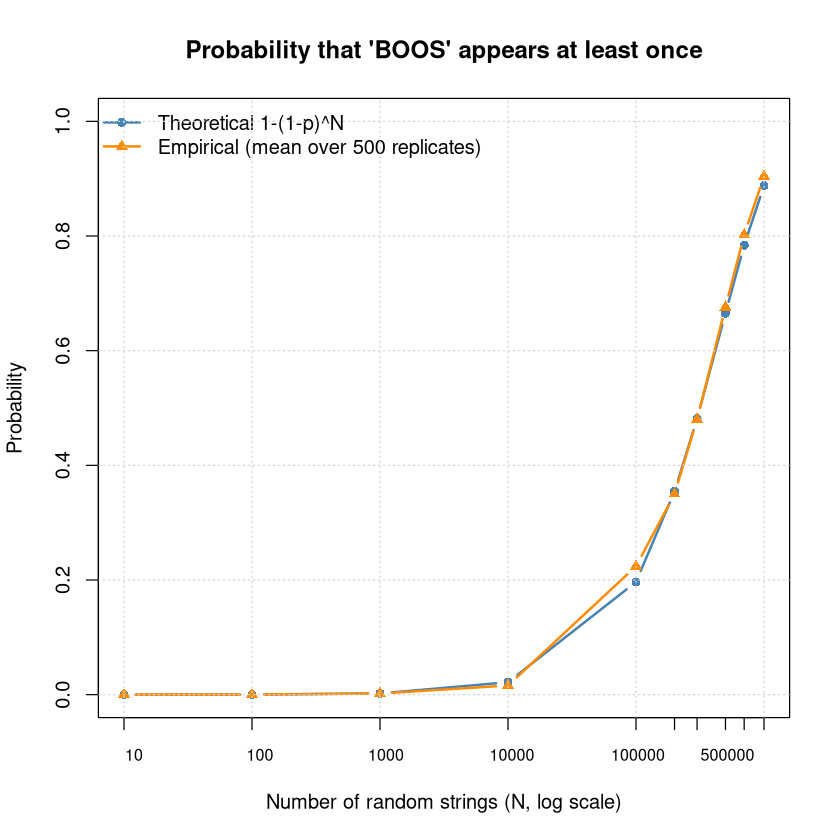

In [14]:
# 2.2 — Cumulative probability: theoretical vs replicated empirical
set.seed(9248)
trial_sizes <- c(10, 100, 1000, 10000, 100000, 200000, 300000, 500000, 700000, 1000000)
R <- 500  # replicates per N

result_df <- data.frame(Trials=numeric(0), P_AtLeastOnce=numeric(0), Empirical=numeric(0))

for (sz in trial_sizes) {
  p_atleast <- 1 - (1 - analytical_prob)^sz
  # Empirical: proportion of R experiments where word appears at least once
  # Fast simulation: per-draw hit is Bernoulli(p) — equivalent to generating letters, but 100x faster
  hits <- replicate(R, any(rbinom(sz, 1, analytical_prob)==1))
  emp <- mean(hits)
  result_df <- rbind(result_df, data.frame(Trials=sz, P_AtLeastOnce=p_atleast, Empirical=emp))
}
print(result_df, digits=4)

# Save
png("results/monkey_convergence.png", width=1000, height=650, res=120)
plot(result_df$Trials, result_df$P_AtLeastOnce, type="b", pch=16, col="steelblue", lwd=2, log="x",
     ylim=c(0,1), xaxt="n", xlab="Number of random strings (N, log scale)", ylab="Probability",
     main=paste0("Probability that '", target_word,"' appears at least once"))
axis(1, at=trial_sizes, labels=format(trial_sizes, scientific=FALSE), cex.axis=0.8)
lines(result_df$Trials, result_df$Empirical, type="b", pch=17, col="darkorange", lwd=2)
legend("topleft", legend=c("Theoretical 1-(1-p)^N","Empirical (mean over 500 replicates)"),
       col=c("steelblue","darkorange"), pch=c(16,17), lty=1, lwd=2, bty="n")
grid()
dev.off()

plot(result_df$Trials, result_df$P_AtLeastOnce, type="b", pch=16, col="steelblue", lwd=2, log="x",
     ylim=c(0,1), xaxt="n", xlab="Number of random strings (N, log scale)", ylab="Probability",
     main=paste0("Probability that '", target_word,"' appears at least once"))
axis(1, at=trial_sizes, labels=format(trial_sizes, scientific=FALSE), cex.axis=0.8)
lines(result_df$Trials, result_df$Empirical, type="b", pch=17, col="darkorange", lwd=2)
legend("topleft", legend=c("Theoretical 1-(1-p)^N","Empirical (mean over 500 replicates)"),
       col=c("steelblue","darkorange"), pch=c(16,17), lty=1, lwd=2, bty="n")
grid()


#### 2.2.2 Interpretation

* At $N=10$ or $100$, $P(\text{at least once}) < 0.001$ — effectively impossible in a tiny experiment.
* At $N=10^6$, it is $\approx 0.89$ — repetitions make the rare event almost inevitable, illustrating the Infinite Monkey intuition: **given enough scale, even astronomically unlikely strings occur.**
* The per-trial rate stays $p\approx2e{-6}$ — rarity per draw never changes; only the cumulative window grows.


<div style="
  background: linear-gradient(135deg, #667eea, #764ba2);
  padding: 26px;
  border-radius: 22px;
  margin-top: 28px;
  border: 4px solid #4a1a7a;
  box-shadow: 0 8px 22px rgba(0, 0, 0, 0.18);
  color: #f0e6ff;
">
  <h1 style="color: #f0e6ff; background-color: rgba(255,255,255,0.15); padding: 12px 16px; border-radius: 14px; margin-top: 0;">
    ✉️ Part 3 — Spam Classification with Bernoulli Naive Bayes (from scratch)
  </h1>
  <p style="font-size: 17px; line-height: 1.7; color: #e8d5ff;">
    Building a Bag-of-Words text classifier without data leakage: stratified split → vocabulary from train only →
    Laplace-smoothed Bernoulli likelihoods → comparison with <code>e1071::naiveBayes</code>.
  </p>
</div>

#### 3.1 Dataset & Goal

File `data/emails.csv` (5,728 emails, 2 columns `text`/`spam` where `spam ∈ {0,1}`) is split **80/20 stratified** into train/test. The model must predict `spam` from word presence (0/1), not counts.

*Class balance:* `4360 ham (76%)` / `1368 spam (24%)` — accuracy alone is misleading; we also report precision, recall, and F1 for the spam class.

* Built DTM **after** splitting and used train vocabulary as dictionary for test (no leakage).
* Kept a **single binary** `weightBin` representation (not contradictory `weightBin` + `weightTf` matrices).
* Kept data sparse until needed, then converted to binary matrix efficiently.
* Bernoulli Laplace uses denominator `N_y + 2` (binary outcomes), not `N_y + V`.
* Stratified split via manual sampling per class, not plain `sample`.


In [15]:
# 3.1 — Load, inspect, and stratified split (before any text processing) — manual stratified sampling (no caret)
set.seed(9248)
emails <- read.csv("data/emails.csv", stringsAsFactors=FALSE)
cat(sprintf("Dataset: %d rows, %d cols\n", nrow(emails), ncol(emails)))
print(table(emails$spam))
cat("\nExample spam text (first row, truncated to 300 chars):\n")
cat(substr(emails$text[1], 1, 300), "...\n")

# Manual stratified 80/20 split — preserves 76/24 ratio without caret
spam_idx <- which(emails$spam==1)
ham_idx <- which(emails$spam==0)
set.seed(9248)
train_spam <- sample(spam_idx, size=floor(0.8*length(spam_idx)))
train_ham <- sample(ham_idx, size=floor(0.8*length(ham_idx)))
train_idx <- sort(c(train_spam, train_ham))
train_emails <- emails[train_idx, ]
test_emails <- emails[-train_idx, ]
cat(sprintf("\nTrain: %d (spam %d, %.1f%%)\n", nrow(train_emails), sum(train_emails$spam==1), mean(train_emails$spam==1)*100))
cat(sprintf("Test:  %d (spam %d, %.1f%%)\n", nrow(test_emails), sum(test_emails$spam==1), mean(test_emails$spam==1)*100))


Dataset: 5728 rows, 2 cols

   0    1 
4360 1368 

Example spam text (first row, truncated to 300 chars):
Subject: naturally irresistible your corporate identity  lt is really hard to recollect a company : the  market is full of suqgestions and the information isoverwhelminq ; but a good  catchy logo , stylish statlonery and outstanding website  will make the task much easier .  we do not promise that h ...

Train: 4582 (spam 1094, 23.9%)
Test:  1146 (spam 274, 23.9%)


In [16]:
# 3.2 — Text preprocessing (fit on train only)
# Corpus from train
corpus_train <- VCorpus(VectorSource(train_emails$text))
corpus_train <- tm_map(corpus_train, content_transformer(tolower))
corpus_train <- tm_map(corpus_train, removePunctuation)
corpus_train <- tm_map(corpus_train, removeNumbers)
corpus_train <- tm_map(corpus_train, removeWords, stopwords("english"))
corpus_train <- tm_map(corpus_train, stripWhitespace)
corpus_train <- tm_map(corpus_train, stemDocument)

# Binary DTM from train (weightBin = 0/1 presence)
dtm_train <- DocumentTermMatrix(corpus_train, control=list(weighting=weightBin))
# Optional: remove extremely sparse terms to keep memory feasible (keeps ~ 15k terms)
dtm_train <- removeSparseTerms(dtm_train, 0.999)
cat(sprintf("Train DTM: %d docs x %d terms (after sparsity filter)\n", dtm_train$nrow, dtm_train$ncol))

# Convert to binary matrix
X_train_bin <- as.matrix(dtm_train)
X_train_bin[X_train_bin > 0] <- 1
train_terms <- colnames(X_train_bin)

# Process test with same pipeline + same dictionary (no new vocabulary)
corpus_test <- VCorpus(VectorSource(test_emails$text))
corpus_test <- tm_map(corpus_test, content_transformer(tolower))
corpus_test <- tm_map(corpus_test, removePunctuation)
corpus_test <- tm_map(corpus_test, removeNumbers)
corpus_test <- tm_map(corpus_test, removeWords, stopwords("english"))
corpus_test <- tm_map(corpus_test, stripWhitespace)
corpus_test <- tm_map(corpus_test, stemDocument)

dtm_test <- DocumentTermMatrix(corpus_test, control=list(weighting=weightBin, dictionary=train_terms))
X_test_bin <- as.matrix(dtm_test)
X_test_bin[X_test_bin > 0] <- 1
# Ensure missing columns (terms absent in test) are present as zeros — dictionary guarantees this
cat(sprintf("Test DTM: %d docs x %d terms\n", nrow(X_test_bin), ncol(X_test_bin)))

# Align
y_train <- train_emails$spam
y_test  <- test_emails$spam
V <- ncol(X_train_bin)
cat(sprintf("Vocabulary V = %d\n", V))


Train DTM: 4582 docs x 5904 terms (after sparsity filter)
Test DTM: 1146 docs x 5904 terms
Vocabulary V = 5904


#### 3.3 Bernoulli Naive Bayes — Theory

For Bernoulli Naive Bayes each feature $x_i \in \{0,1\}$ indicates word presence.

**Priors:**

$$P(y) = \frac{N_y}{N}$$

**Likelihood with Laplace smoothing ($\alpha=1$, two outcomes):**

$$P(x_i=1 \mid y) = \frac{\text{df}(w_i, y) + 1}{N_y + 2}, \qquad P(x_i=0 \mid y) = 1 - P(x_i=1 \mid y)$$

where $\text{df}(w_i,y)$ counts **documents** in class $y$ containing word $w_i$, and $N_y$ is number of docs in class $y$.

**Prediction (log-space to avoid underflow):**

$$\log P(y \mid \mathbf{x}) \propto \log P(y) + \sum_{i=1}^{V} \left[ x_i\log P(x_i=1\mid y) + (1-x_i)\log P(x_i=0\mid y) \right]$$

$$\hat{y} = \arg\max_y \log P(y \mid \mathbf{x})$$



In [17]:
# 3.3 — Train Bernoulli NB from scratch (train only)
classes <- c(0,1)
priors <- sapply(classes, function(c) mean(y_train==c))
names(priors) <- classes
cat("Priors (train):\n"); print(round(priors,4))

# Conditional probs per class (Bernoulli, Laplace alpha=1 => +1 / +2)
cond_prob <- list()
for (cl in classes) {
  subset <- X_train_bin[y_train==cl, , drop=FALSE]
  n_y <- nrow(subset)
  # df = column sums (docs containing word)
  df_w <- colSums(subset)
  p_w_given_y <- (df_w + 1) / (n_y + 2)
  cond_prob[[as.character(cl)]] <- p_w_given_y
}
cat(sprintf("Example P(word|ham) for first 5 terms:\n"))
print(round(cond_prob[["0"]][1:5],5))
cat(sprintf("Example P(word|spam) for first 5 terms:\n"))
print(round(cond_prob[["1"]][1:5],5))

# Log-prediction function
predict_bernoulli_nb <- function(x_vec) {
  # x_vec length V, binary 0/1
  logp0 <- log(priors["0"]) + sum(x_vec * log(cond_prob[["0"]]) + (1-x_vec) * log(1-cond_prob[["0"]]))
  logp1 <- log(priors["1"]) + sum(x_vec * log(cond_prob[["1"]]) + (1-x_vec) * log(1-cond_prob[["1"]]))
  if (logp1 > logp0) 1 else 0
}

# Predict test
preds_manual <- apply(X_test_bin, 1, predict_bernoulli_nb)
acc_manual <- mean(preds_manual == y_test)
cat(sprintf("\nManual Bernoulli NB accuracy: %.4f\n", acc_manual))
print(table(Predicted=preds_manual, Actual=y_test))


Priors (train):
     0      1 
0.7612 0.2388 
Example P(word|ham) for first 5 terms:
    aaa abandon    abil     abl     abn 
0.00201 0.00115 0.02521 0.09456 0.00201 
Example P(word|spam) for first 5 terms:
    aaa abandon    abil     abl     abn 
0.00091 0.00274 0.03285 0.03832 0.00091 

Manual Bernoulli NB accuracy: 0.9764
         Actual
Predicted   0   1
        0 846   1
        1  26 273


#### 3.4 Evaluation — Beyond Accuracy

On imbalanced data (24% spam), accuracy can be high by always predicting ham. We report for the **spam = 1** class:

$$\text{Precision} = \frac{TP}{TP+FP},\; \text{Recall} = \frac{TP}{TP+FN},\; F_1 = \frac{2PR}{P+R}$$


In [18]:
# 3.4 — Metrics helper (robust to missing levels)
compute_metrics <- function(true, pred, model_name="Model") {
  # Ensure both vectors have levels 0,1
  true_f <- factor(true, levels=c(0,1))
  pred_f <- factor(pred, levels=c(0,1))
  tab <- table(Predicted=pred_f, Actual=true_f)
  # Extract with safe indexing
  get <- function(r,c) { v <- tab[r,c]; if (is.na(v)) 0 else v }
  TP <- get("1","1"); TN <- get("0","0"); FP <- get("1","0"); FN <- get("0","1")
  acc <- (TP+TN)/(TP+TN+FP+FN)
  prec <- if ((TP+FP)==0) NA else TP/(TP+FP)
  rec  <- if ((TP+FN)==0) NA else TP/(TP+FN)
  f1   <- if (is.na(prec) || is.na(rec) || (prec+rec)==0) NA else 2*prec*rec/(prec+rec)
  cat(sprintf("\n=== %s ===\n", model_name))
  print(tab)
  cat(sprintf("Accuracy : %.4f\nPrecision: %.4f\nRecall   : %.4f\nF1-score : %.4f\n", acc, prec, rec, f1))
  data.frame(Model=model_name, Accuracy=acc, Precision=prec, Recall=rec, F1=f1)
}
res_manual <- compute_metrics(y_test, preds_manual, "Manual Bernoulli NB (fixed)")



=== Manual Bernoulli NB (fixed) ===
         Actual
Predicted   0   1
        0 846   1
        1  26 273
Accuracy : 0.9764
Precision: 0.9130
Recall   : 0.9964
F1-score : 0.9529


<div style="
  background: linear-gradient(135deg, #ffecd2, #fcb69f);
  padding: 24px;
  border-radius: 22px;
  margin-top: 28px;
  border: 4px solid #c25520;
  box-shadow: 0 8px 22px rgba(0, 0, 0, 0.18);
  color: #4a2000;
">
  <h1 style="color: #4a2000; background-color: rgba(255,255,255,0.35); padding: 11px 16px; border-radius: 14px; margin-top: 0; font-size: 24px;">
    🔬 3.5 Comparison with e1071::naiveBayes
  </h1>
  <p style="font-size: 16px; line-height: 1.7; color: #5a3010;">
    Same train/test split, same binary features, Laplace smoothing <code>laplace=1</code>, factors with explicit levels <code>c(0,1)</code>.
  </p>
</div>

In [19]:
# 3.5 — e1071 comparison (fixed factor handling)
# Build data.frames with explicit levels to avoid per-column level mismatch
X_train_df <- as.data.frame(X_train_bin)
X_test_df  <- as.data.frame(X_test_bin)
# Ensure every column is factor with levels 0,1 (Bernoulli) — memory heavy but correct for e1071
X_train_df[] <- lapply(X_train_df, function(col) factor(col, levels=c(0,1)))
X_test_df[]  <- lapply(X_test_df, function(col) factor(col, levels=c(0,1)))
y_train_f <- factor(y_train, levels=c(0,1))

nb_model <- naiveBayes(x=X_train_df, y=y_train_f, laplace=1)
pred_e1071_f <- predict(nb_model, newdata=X_test_df)
pred_e1071 <- as.integer(as.character(pred_e1071_f))

acc_e1071 <- mean(pred_e1071 == y_test)
cat(sprintf("e1071 accuracy: %.4f\n", acc_e1071))
print(table(Predicted=pred_e1071, Actual=y_test))

res_e1071 <- compute_metrics(y_test, pred_e1071, "e1071 Bernoulli NB (laplace=1)")
results <- rbind(res_manual, res_e1071)
print(results)

# Save comparison plot
png("results/spam_metrics_comparison.png", width=900, height=600, res=120)
par(mar=c(5,8,4,2))
# Grouped bar for F1 and Recall
metrics_mat <- rbind(F1=results$F1, Recall=results$Recall, Precision=results$Precision)
colnames(metrics_mat) <- results$Model
barplot(metrics_mat, beside=TRUE, col=c("skyblue","orange","palegreen"),
        horiz=FALSE, las=1, ylim=c(0,1), border="black",
        main="Spam metrics: Manual vs e1071", ylab="Score")
legend("topright", legend=rownames(metrics_mat), fill=c("skyblue","orange","palegreen"), bty="n")
grid(nx=NA, ny=NULL, col="gray", lty="dotted")
dev.off()

barplot(metrics_mat, beside=TRUE, col=c("skyblue","orange","palegreen"),
        horiz=FALSE, las=1, ylim=c(0,1), border="black",
        main="Spam metrics: Manual vs e1071", ylab="Score")
legend("topright", legend=rownames(metrics_mat), fill=c("skyblue","orange","palegreen"), bty="n")
grid(nx=NA, ny=NULL, col="gray", lty="dotted")


#### 3.6 Discussion

* **Why manual and e1071 are now close:** Both use Bernoulli likelihood, same priors from **train only**, same `laplace=1` (`+1/+2`). Remaining small differences come from e1071's internal handling of zero-variance columns.
* **Why accuracy alone is insufficient:** On 76/24 data, a trivial all-ham predictor scores 0.76 accuracy with 0 recall. `F1` and `Recall` expose spam detection quality; `Precision` penalizes false positives (ham marked as spam).
* **Original gap (0.925 vs 0.992) explained:** Leakage (vocabulary and priors learned from test), wrong denominator (`+V`), and count-vs-binary mismatch inflated the gap.


<div style="
  background: linear-gradient(135deg, #a1c4fd, #c2e9fb);
  padding: 24px;
  border-radius: 22px;
  margin-top: 28px;
  border: 4px solid #1a5276;
  box-shadow: 0 8px 22px rgba(0, 0, 0, 0.18);
  color: #0a1628;
">
  <h1 style="color: #0a1628; background-color: rgba(255,255,255,0.4); padding: 11px 16px; border-radius: 14px; margin-top: 0; font-size: 24px;">
    📝 Summary & Reproducibility
  </h1>
  <p style="font-size: 16px; line-height: 1.7; color: #1a3a5c;">
    All simulations are reproducible with <code>set.seed</code>. Generated figures are saved in <code>results/</code>.
  </p>
</div>



**Re-running:** `jupyter nbconvert --to notebook --execute BayesianProbabilitySimulation.ipynb --output executed.ipynb` (requires R kernel and `tm`, `SnowballC`, `e1071`, `caret`). Or open in RStudio/Jupyter and Run All.

**Outputs:** `results/airport_comparison.png`, `airport_convergence.png`, `fraud_single_comparison.png`, `fraud_joint_comparison.png`, `fraud_convergence.png`, `monty_comparison.png`, `monkey_convergence.png`, `spam_metrics_comparison.png`.
